## <span>Desafio Técnico Projetos/Dados Linked -2026</span>

- Note que o CSV passado já está normalizado, não necessitando de transformações em tipo e/ou configurações a respeito dos dados, o que facilita o trabalho, permitindo me concentrar já nos dados brutos.
- Já possui colunas bem definidas com informações relevantes, facilitando a organização relacional dos dados, no caso de persistência num banco de dados posteriormente.
- A princípio pensei em imprimir informações disponibilizadas pelas colunas do CSV, para ter noção básica dos aspectos gerais dos dados e oque ele já pode nos fornecer sem relacionar suas colunas. 
    . Para isso vou usar basicamente as propriedades dos dataframes no pandas

In [ ]:
import pandas as pd

df = pd.read_csv('vendas_linked_ps.csv')

metricas = {
    "Customer Region Distribution": df['customer_region'].value_counts(),
    "Product Category Distribution": df['product_category'].value_counts(),
    "Total Sales": f"R$ {df['total_value'].sum():,.2f}", 
    "Payment Method Distribution": df['payment_method'].value_counts(),
    "Order Status Distribution": df['order_status'].value_counts()
}

for titulo, resultado in metricas.items():
    print(f"\n{'='*15} {titulo}:")
    print(resultado)


=============== Customer Region Distribution:
customer_region
Sudeste         422
Nordeste        279
Sul             245
Centro-Oeste    129
Norte           125
Name: count, dtype: int64

=============== Product Category Distribution:
product_category
Beleza           224
Moda             219
Eletrônicos      201
Esportes         191
Casa e Jardim    186
Livros           179
Name: count, dtype: int64

=============== Total Sales:
R$ 375,239.28

=============== Payment Method Distribution:
payment_method
Cartao    545
PIX       477
Boleto    178
Name: count, dtype: int64

=============== Order Status Distribution:
order_status
Entregue       953
Cancelado      125
Em transito    122
Name: count, dtype: int64


- Do resultado anterior, podemos ter tirar algumas percepções do que realizar com os dados, por exemplo:
    Percepções Iniciais (Análise Descritiva):

        .Separação dos dados por região;
        .Quantidade total arrecadada nas vendas (distinguindo receita bruta de receita líquida);
        .Qual o produto que mais vende e o que menos sai (em volume e valor);
        .Porcentagem de produtos entregues, em trânsito e cancelados;
        .Qual o tipo de pagamento mais recorrente;
        .Preço médio dos produtos por categoria e geral.

- Agora, se quisermos optar por análises mais complexas, também podemos relacionar os dados de forma a gerar novos conhecimentos.
    Relacionando os dados:

        .Comportamento Geográfico e Temporal: Qual região teve mais pedidos entregues e realizou mais vendas? (E estruturar a volumetria para acompanhar a evolução em faixas de tempo maiores, como 30, 60 ou 90 dias, conforme o histórico crescer);

        .Dos produtos vendidos, quais são suas categorias e média de preço por categoria?

        .Segmentação de Portfólio: Realizar a separação de produtos em subcategorias/faixas de preço por saída de venda (ex: avaliar se produtos do subtipo "Premium" geram mais receita que os de baixo valor, além de monitorar a dependência do faturamento em um único SKU de alto valor);

        .Análise de Sazonalidade Semanal: Cruzar os dados em relação aos dias da ordem de pedido para identificar se as compras são realizadas mais em fins de semana ou em dias específicos da semana;

        .Correlação de Cancelamentos: Quantidade de pedidos cancelados relacionando com produtos e métodos de pagamento, para identificar se há alguma tendência ou padrão de risco de cancelamento para certos tipos de transações.



## <span>Análise Descritiva</span>

In [6]:
print("==================================================")
print("           INÍCIO DA ANÁLISE DESCRITIVA           ")
print("==================================================\n")

# -------------------------------------------------------------------------
# 1. Separação dos dados por região
# -------------------------------------------------------------------------
print("1. SEPARAÇÃO DOS DADOS POR REGIÃO (Volume de Pedidos e Faturamento)")
analise_regiao = df.groupby('customer_region').agg(
    Qtd_Pedidos=('order_id', 'count'),
    Faturamento_Bruto=('total_value', 'sum')
).sort_values(by='Qtd_Pedidos', ascending=False)

# Formatando a coluna de faturamento para exibição
analise_regiao['Faturamento_Bruto'] = analise_regiao['Faturamento_Bruto'].apply(lambda x: f"R$ {x:,.2f}")
print(analise_regiao)
print("-" * 50)


# -------------------------------------------------------------------------
# 2. Quantidade total arrecadada (Receita Bruta vs Líquida)
# -------------------------------------------------------------------------
print("\n2. QUANTIDADE TOTAL ARRECADADA NAS VENDAS")
receita_bruta = df['total_value'].sum()
# Receita líquida desconsidera pedidos com status 'Cancelado'
receita_liquida = df[df['order_status'] != 'Cancelado']['total_value'].sum()

print(f"Receita Bruta (Total Transacionado): R$ {receita_bruta:,.2f}")
print(f"Receita Líquida (Excluindo Cancelados): R$ {receita_liquida:,.2f}")
print(f"Total Perdido em Cancelamentos: R$ {(receita_bruta - receita_liquida):,.2f}")
print("-" * 50)


# -------------------------------------------------------------------------
# 3. Qual o produto que mais vende e o que menos sai (Volume e Valor)
# -------------------------------------------------------------------------
print("\n3. PRODUTOS QUE MAIS VENDEM E QUE MENOS SAEM")

# Agrupando por produto para obter volume (quantity) e valor total (total_value)
df_produtos = df.groupby('product_name').agg(
    Volume_Total=('quantity', 'sum'),
    Valor_Total=('total_value', 'sum')
)

# A) Visão por Volume (Quantidade)
prod_mais_vendido_vol = df_produtos['Volume_Total'].idxmax()
qtd_mais_vendido_vol = df_produtos['Volume_Total'].max()

prod_menos_vendido_vol = df_produtos['Volume_Total'].idxmin()
qtd_menos_vendido_vol = df_produtos['Volume_Total'].min()

# B) Visão por Valor (Faturamento)
prod_mais_vendido_val = df_produtos['Valor_Total'].idxmax()
val_mais_vendido_val = df_produtos['Valor_Total'].max()

prod_menos_vendido_val = df_produtos['Valor_Total'].idxmin()
val_menos_vendido_val = df_produtos['Valor_Total'].min()

print(f"-> Maior Volume: '{prod_mais_vendido_vol}' ({qtd_mais_vendido_vol} unidades)")
print(f"-> Menor Volume: '{prod_menos_vendido_vol}' ({qtd_menos_vendido_vol} unidades)")
print(f"-> Maior Faturamento: '{prod_mais_vendido_val}' (R$ {val_mais_vendido_val:,.2f})")
print(f"-> Menor Faturamento: '{prod_menos_vendido_val}' (R$ {val_menos_vendido_val:,.2f})")
print("-" * 50)


# -------------------------------------------------------------------------
# 4. Porcentagem de produtos entregues, em trânsito e cancelados
# -------------------------------------------------------------------------
print("\n4. STATUS DOS PEDIDOS (Distribuição Percentual)")
status_percentual = df['order_status'].value_counts(normalize=True) * 100
for status, perc in status_percentual.items():
    print(f"- {status}: {perc:.2f}%")
print("-" * 50)


# -------------------------------------------------------------------------
# 5. Qual o tipo de pagamento mais recorrente
# -------------------------------------------------------------------------
print("\n5. MEIO DE PAGAMENTO MAIS RECORRENTE")
pagamento_recorrente = df['payment_method'].value_counts()
print(f"O método mais utilizado é o '{pagamento_recorrente.idxmax()}' com {pagamento_recorrente.max()} pedidos.")
print("\nDistribuição completa por pedidos:")
print(pagamento_recorrente)
print("-" * 50)


# -------------------------------------------------------------------------
# 6. Preço médio dos produtos por categoria e geral
# -------------------------------------------------------------------------
print("\n6. PREÇO MÉDIO DOS PRODUTOS")

# Média Geral
preco_medio_geral = df['unit_price'].mean()
print(f"Preço Médio Geral dos Produtos: R$ {preco_medio_geral:,.2f}\n")

# Média por Categoria
print("Preço Médio por Categoria de Produto:")
preco_medio_categoria = df.groupby('product_category')['unit_price'].mean().sort_values(ascending=False)
for cat, preco in preco_medio_categoria.items():
    print(f"- {cat}: R$ {preco:,.2f}")

print("\n==================================================")
print("             FIM DA ANÁLISE DESCRITIVA            ")
print("==================================================")

           INÍCIO DA ANÁLISE DESCRITIVA           

1. SEPARAÇÃO DOS DADOS POR REGIÃO (Volume de Pedidos e Faturamento)
                 Qtd_Pedidos Faturamento_Bruto
customer_region                               
Sudeste                  422     R$ 139,934.83
Nordeste                 279     R$ 103,201.93
Sul                      245      R$ 65,468.84
Centro-Oeste             129      R$ 37,098.86
Norte                    125      R$ 29,534.82
--------------------------------------------------

2. QUANTIDADE TOTAL ARRECADADA NAS VENDAS
Receita Bruta (Total Transacionado): R$ 375,239.28
Receita Líquida (Excluindo Cancelados): R$ 336,872.15
Total Perdido em Cancelamentos: R$ 38,367.13
--------------------------------------------------

3. PRODUTOS QUE MAIS VENDEM E QUE MENOS SAEM
-> Maior Volume: 'Protetor Solar FPS 60' (77 unidades)
-> Menor Volume: 'Tênis de Corrida Nike' (32 unidades)
-> Maior Faturamento: 'Bicicleta Speed Aro 29' (R$ 64,718.12)
-> Menor Faturamento: 'Regador de Jard

## <span>Relacionando os Dados</span>

In [7]:
import numpy as np

# Lendo o arquivo CSV solicitado
df = pd.read_csv('vendas_linked_ps.csv')

# Garantindo que a coluna de data está no formato correto para análise temporal
df['order_date'] = pd.to_datetime(df['order_date'])

print("==================================================")
print("          INÍCIO DA ANÁLISE AVANÇADA             ")
print("==================================================\n")

# -------------------------------------------------------------------------
# 1. Comportamento Geográfico e Temporal
# -------------------------------------------------------------------------
print("1. COMPORTAMENTO GEOGRÁFICO E TEMPORAL")
# Filtrando apenas pedidos que geraram receita de fato (Entregue e Em trânsito)
df_vendas_reais = df[df['order_status'] != 'Cancelado']

geo_temporal = df_vendas_reais.groupby('customer_region').agg(
    Pedidos_Entregues=('order_id', 'count'),
    Receita_Liquida=('total_value', 'sum')
).sort_values(by='Receita_Liquida', ascending=False)

geo_temporal['Receita_Liquida'] = geo_temporal['Receita_Liquida'].apply(lambda x: f"R$ {x:,.2f}")
print("Pedidos e Receita Líquida por Região:")
print(geo_temporal)
print("\n*Nota para o Dashboard: Como a base atual cobre apenas o período de 01/01/2024 a 09/01/2024, "
      "\na volumetria temporal (30, 60, 90 dias) deve ser implementada via eixos dinâmicos de data.")
print("-" * 50)


# -------------------------------------------------------------------------
# 2. Categorias e Média de Preço dos Produtos Vendidos
# -------------------------------------------------------------------------
print("\n2. PRODUTOS VENDIDOS: CATEGORIAS E MÉDIA DE PREÇO")
# Agrupando por categoria para ver a quantidade de produtos distintos e preço médio unitário
cat_preco = df.groupby('product_category').agg(
    Qtd_Produtos_Distintos=('product_name', 'nunique'),
    Preco_Medio_Unitario=('unit_price', 'mean'),
    Total_Itens_Vendidos=('quantity', 'sum')
).sort_values(by='Total_Itens_Vendidos', ascending=False)

cat_preco['Preco_Medio_Unitario'] = cat_preco['Preco_Medio_Unitario'].apply(lambda x: f"R$ {x:,.2f}")
print(cat_preco)
print("-" * 50)


# -------------------------------------------------------------------------
# 3. Segmentação de Portfólio (Faixas de Preço e Dependência de SKU)
# -------------------------------------------------------------------------
print("\n3. SEGMENTAÇÃO DE PORTFÓLIO E DEPENDÊNCIA DE SKU")

# A) Criando faixas de preço (Buckets) usando bins lógicos
bins = [0, 50, 150, float('inf')]
labels = ['Baixo Valor (< R$50)', 'Médio Valor (R$50 - R$150)', 'Premium (> R$150)']
df['faixa_preco'] = pd.cut(df['unit_price'], bins=bins, labels=labels)

segmentacao_faixa = df.groupby('faixa_preco', observed=False).agg(
    Volume_Vendas=('quantity', 'sum'),
    Receita_Bruta=('total_value', 'sum')
)
segmentacao_faixa['Representatividade_Receita'] = (segmentacao_faixa['Receita_Bruta'] / df['total_value'].sum() * 100).apply(lambda x: f"{x:.2f}%")
segmentacao_faixa['Receita_Bruta'] = segmentacao_faixa['Receita_Bruta'].apply(lambda x: f"R$ {x:,.2f}")
print("Análise por Faixa de Preço (Segmentação):")
print(segmentacao_faixa)

# B) Monitoramento de Dependência de um único SKU (Concentração de receita)
top_sku = df.groupby('product_name')['total_value'].sum().sort_values(ascending=False).head(1)
perc_top_sku = (top_sku.values[0] / df['total_value'].sum()) * 100
print(f"\nAlerta de Dependência de SKU:")
print(f"- O produto que mais concentra receita é: '{top_sku.index[0]}'")
print(f"- Ele sozinho representa {perc_top_sku:.2f}% de toda a receita bruta transacionada.")
print("-" * 50)


# -------------------------------------------------------------------------
# 4. Análise de Sazonalidade Semanal
# -------------------------------------------------------------------------
print("\n4. ANÁLISE DE SAZONALIDADE SEMANAL")
# Extraindo o dia da semana em inglês e mapeando para português para o relatório
dias_pt = {
    'Monday': 'Segunda-feira', 'Tuesday': 'Terça-feira', 'Wednesday': 'Quarta-feira',
    'Thursday': 'Quinta-feira', 'Friday': 'Sexta-feira', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df['dia_semana'] = df['order_date'].dt.day_name().map(dias_pt)

sazonalidade = df.groupby('dia_semana').agg(
    Qtd_Pedidos=('order_id', 'count'),
    Receita_Bruta=('total_value', 'sum')
).reindex(['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo'])

sazonalidade['Receita_Bruta'] = sazonalidade['Receita_Bruta'].apply(lambda x: f"R$ {x:,.2f}")
print(sazonalidade)
print("-" * 50)


# -------------------------------------------------------------------------
# 5. Correlação de Cancelamentos
# -------------------------------------------------------------------------
print("\n5. CORRELAÇÃO E TENDÊNCIAS DE CANCELAMENTO")
df_cancelados = df[df['order_status'] == 'Cancelado']

print(f"Total de Pedidos Cancelados no Período: {len(df_cancelados)}")

if len(df_cancelados) > 0:
    # Cruzando produtos cancelados com a forma de pagamento utilizada
    correlacao_cancelamento = pd.crosstab(
        df['product_name'], 
        df['payment_method'], 
        values=df['order_status'].apply(lambda x: 1 if x == 'Cancelado' else 0), 
        aggfunc='sum'
    ).fillna(0).astype(int)
    
    # Filtrando para mostrar apenas produtos que tiveram de fato algum cancelamento
    correlacao_cancelamento = correlacao_cancelamento[correlacao_cancelamento.sum(axis=1) > 0]
    print("\nTabela de Cruzamento (Produto Cancelado vs Método de Pagamento):")
    print(correlacao_cancelamento)
else:
    print("\nNenhum padrão de cancelamento pôde ser mapeado (Zero cancelamentos na base).")

print("\n==================================================")
print("             FIM DA ANÁLISE AVANÇADA              ")
print("==================================================")

          INÍCIO DA ANÁLISE AVANÇADA             

1. COMPORTAMENTO GEOGRÁFICO E TEMPORAL
Pedidos e Receita Líquida por Região:
                 Pedidos_Entregues Receita_Liquida
customer_region                                   
Sudeste                        390   R$ 129,382.82
Nordeste                       248    R$ 92,628.28
Sul                            209    R$ 56,390.28
Centro-Oeste                   111    R$ 30,315.93
Norte                          117    R$ 28,154.84

*Nota para o Dashboard: Como a base atual cobre apenas o período de 01/01/2024 a 09/01/2024, 
a volumetria temporal (30, 60, 90 dias) deve ser implementada via eixos dinâmicos de data.
--------------------------------------------------

2. PRODUTOS VENDIDOS: CATEGORIAS E MÉDIA DE PREÇO
                  Qtd_Produtos_Distintos Preco_Medio_Unitario  \
product_category                                                
Beleza                                 6            R$ 110.94   
Moda                            

. Para facilitar no Dashboard, irei separar as datas para trabalhar com sazonalidade dentro do PowerBI, dessa forma poderei importar dois arquivos distindos em csv, e relacionar suas tabelas direto no BI para trabalhar diferenciando as datas dos produtos.

In [8]:
# Criando a tabela dCalendario baseada no intervalo da sua base
data_min = df['order_date'].min()
data_max = df['order_date'].max()

# Gerando a sequência de dias
d_calendario = pd.DataFrame({'Data': pd.date_range(start=data_min, end=data_max)})

# Extraindo os atributos de tempo
d_calendario['Ano'] = d_calendario['Data'].dt.year
d_calendario['Mes_Num'] = d_calendario['Data'].dt.month
d_calendario['Mes_Nome'] = d_calendario['Data'].dt.strftime('%B') # Nome do mês
d_calendario['Dia'] = d_calendario['Data'].dt.day
d_calendario['Dia_Semana_Num'] = d_calendario['Data'].dt.weekday # 0=Segunda, 6=Domingo
d_calendario['Dia_Semana_Nome'] = d_calendario['Data'].dt.day_name().map(dias_pt)
d_calendario['Eh_Fim_Semana'] = d_calendario['Dia_Semana_Num'].isin([5, 6]).astype(int)

# Salvando a tabela calendário
d_calendario.to_csv('d_calendario.csv', index=False, encoding='utf-8-sig')
print("Tabela dCalendario gerada com sucesso!")

Tabela dCalendario gerada com sucesso!


In [9]:
#exportando a tabela fVendas (df) com as novas colunas criadas (faixa_preco, dia_semana)
df.to_csv('f_vendas_tratada.csv', index=False, encoding='utf-8-sig')
print("Tabela fVendas exportada com sucesso!")

Tabela fVendas exportada com sucesso!


- Agora estamos aptos para prosseguir com o DashBoard no PowerBI, abaixo deixarei a imagem do DashBoard de exemplo, mas você poderá encontra-lo de forma integral no repositório do github.

- Também utilizaremos toda a formatação dos dados apresentados neste notebook, para desenvolver o DashBoard via Streamlit. 
    OBS: Usado os dados filtrados na pasta DATA, f_vendas e d_calendario


## <span>PowerBI Imagem</span>

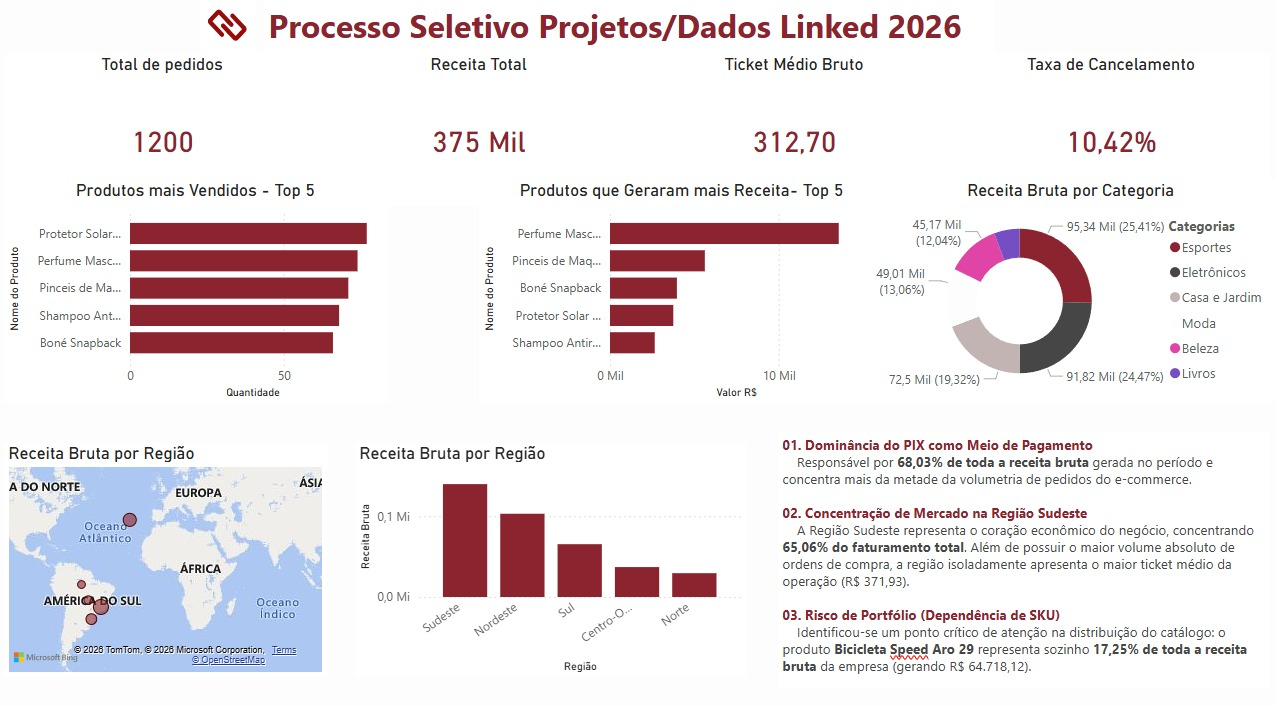

In [11]:
from IPython.display import Image

Image(filename='../data/imagem_powerBI.jpeg')

## <span> Streamlit Imagens</span>

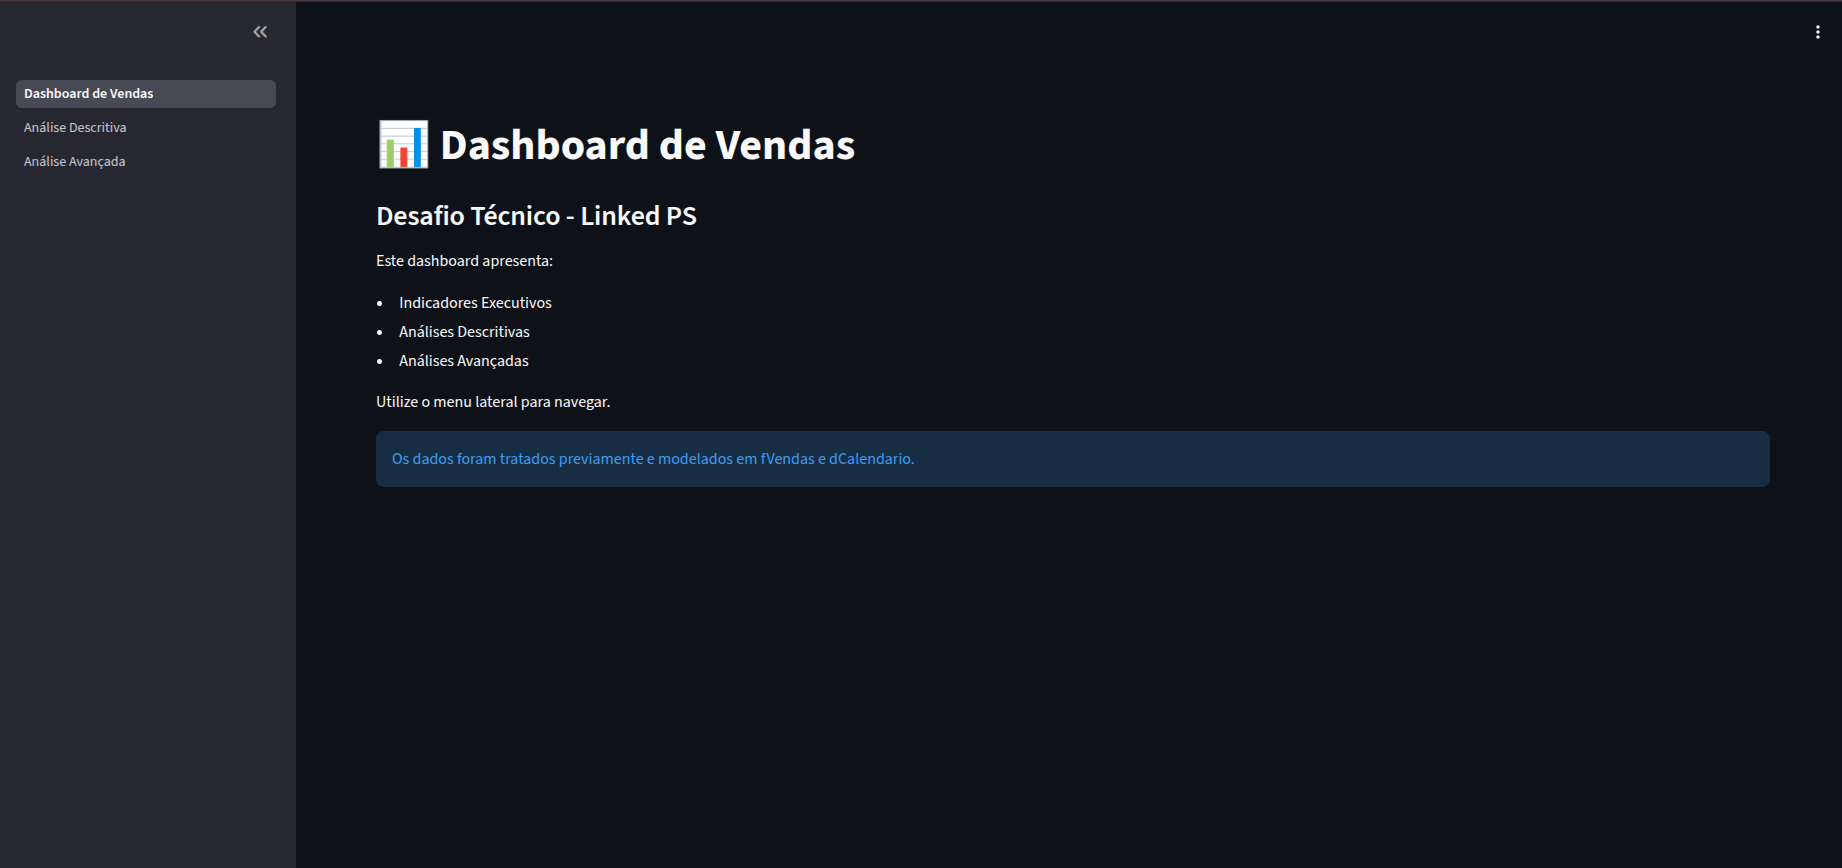

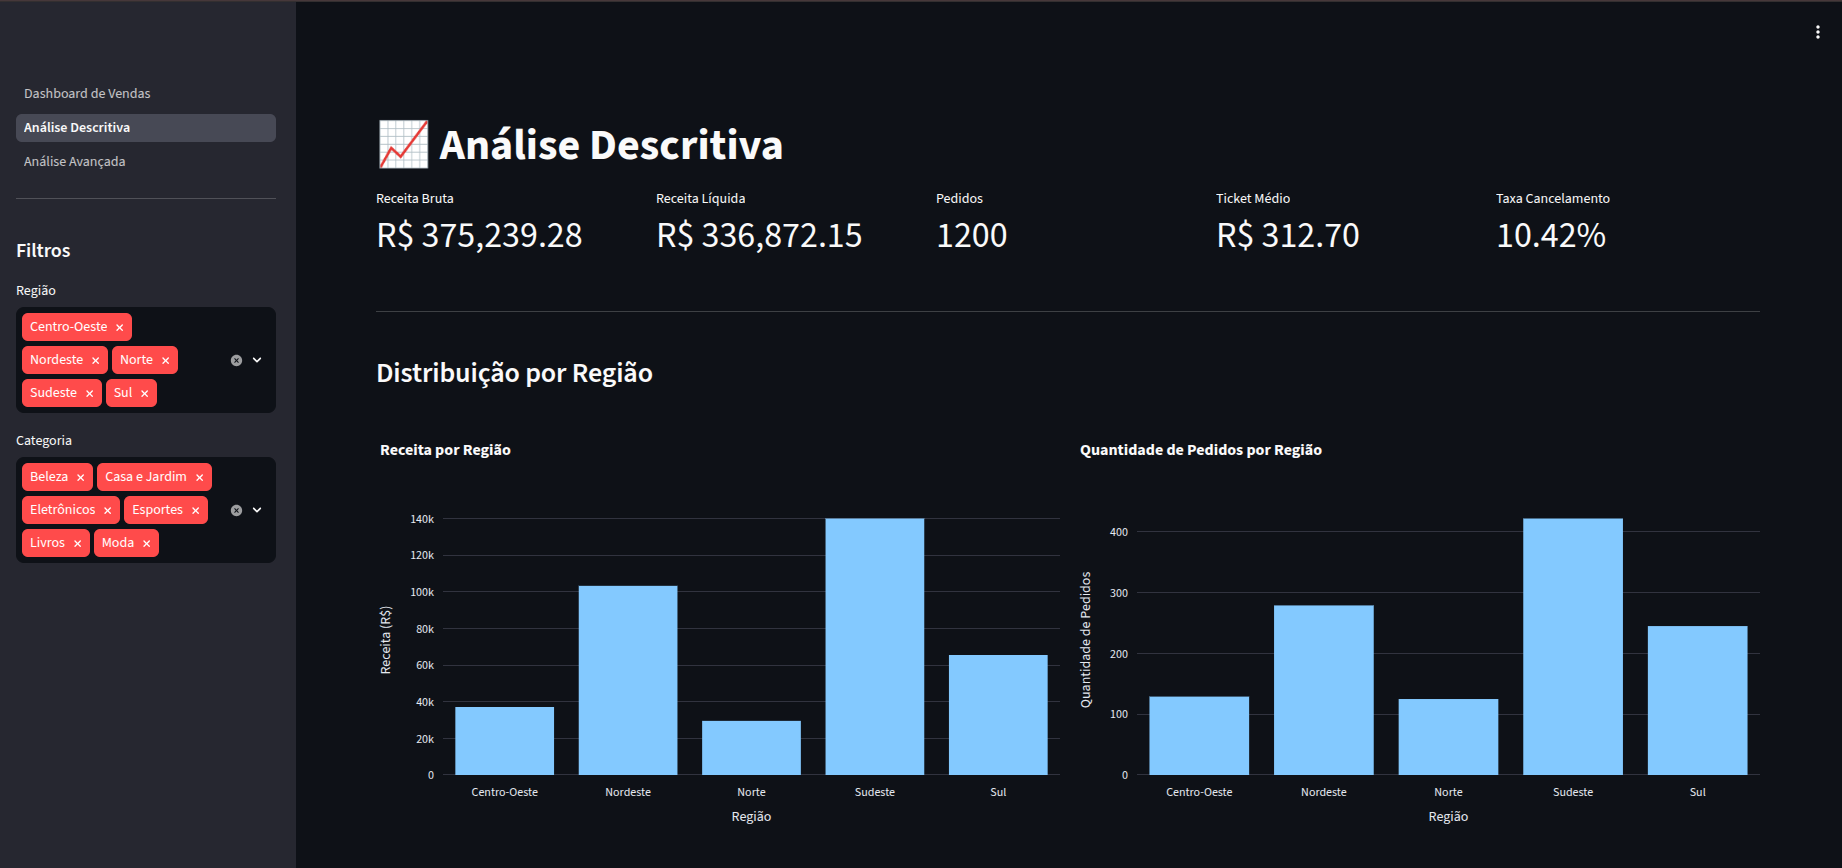

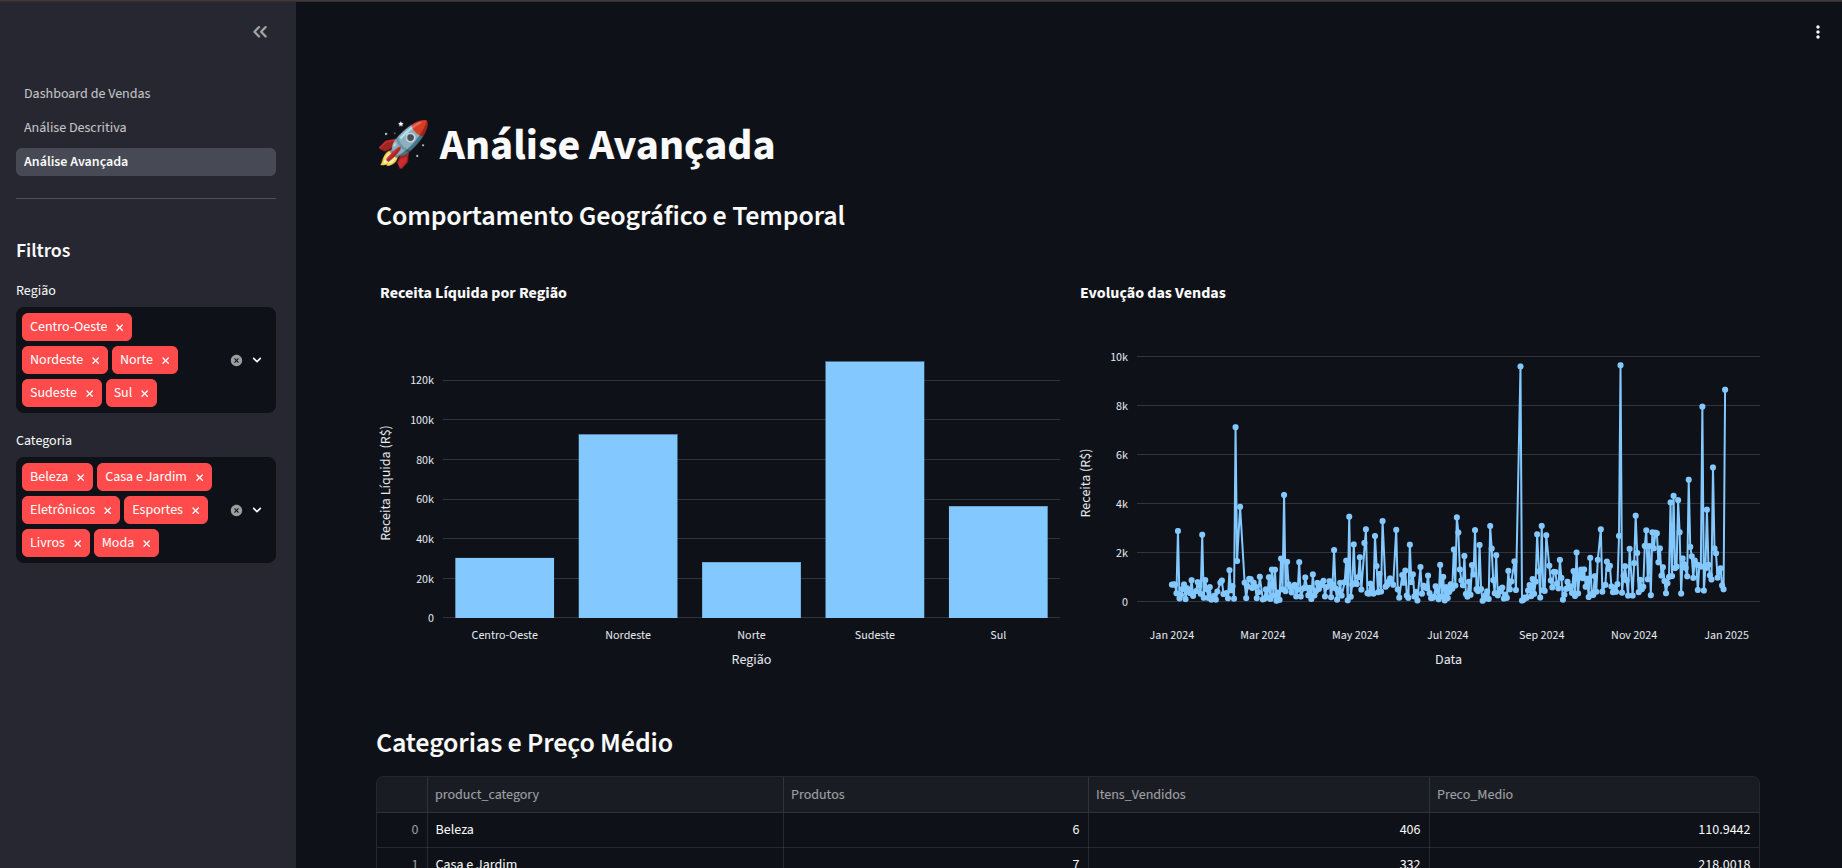

In [14]:
from IPython.display import Image, display

display(Image(filename='../data/Streamlit_1.png'))
display(Image(filename='../data/Streamlit_2.png'))
display(Image(filename='../data/Streamlit_3.png'))